# MNIST and Preprocessing

This notebook introduces the MNIST dataset and the custom preprocessing pipeline used in this project to convert raw drawings into standard input arrays for the neural network.

## Learning Objectives
- Understand the MNIST dataset structure.
- Visualize raw handwritten digits.
- Understand why and how we normalize pixel values.
- See the preprocessing steps applied to user canvas input.

In [1]:
import sys
import pathlib

# Dynamically resolve project root
PROJECT_ROOT = pathlib.Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
    
print(f"Project root added to path: {PROJECT_ROOT}")

Project root added to path: D:\project\DIGIT Recognition


## 1. The MNIST Dataset

MNIST consists of 28x28 grayscale images of handwritten digits (0-9). The images are flattened into 784-element arrays (28 * 28 = 784).

Let's load the dataset using the project's custom loader.

In [2]:
from backend.app.dataset.mnist_loader import load_mnist, get_dataset_info
import matplotlib.pyplot as plt
import numpy as np

# Load a small subset for demonstration
images, labels = load_mnist(split="train", subset_size=1000, flat=False)
print(f"Images shape: {images.shape} (N, H, W)")
print(f"Labels shape: {labels.shape} (N,)")
print(f"Pixel value range: [{images.min()}, {images.max()}]")

Images shape: (1000, 28, 28) (N, H, W)
Labels shape: (1000,) (N,)
Pixel value range: [0.0, 1.0]


### Visualizing Samples

Notice that the background is black (0.0) and the digit is bright (approaching 1.0). This is the standard MNIST convention.

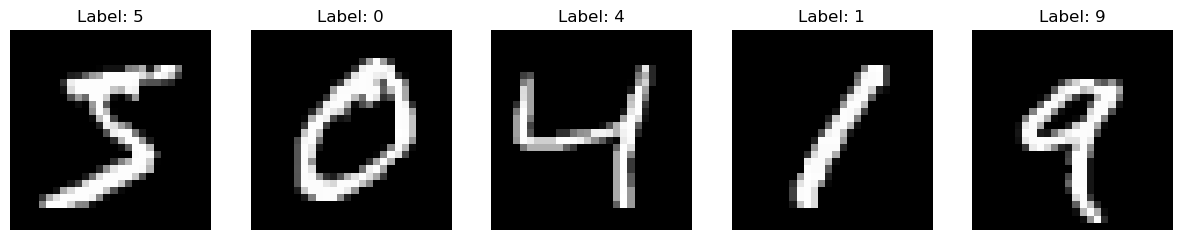

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    axes[i].imshow(images[i], cmap='gray')
    axes[i].set_title(f"Label: {labels[i]}")
    axes[i].axis('off')
plt.show()

## 2. Preprocessing Canvas Drawings

When a user draws a digit on the frontend canvas, it arrives as a base64 PNG. The canvas has a **white background with black ink**, which is the exact opposite of MNIST!

Our `image_processor.py` performs the following:
1. Composites alpha channels onto a white background.
2. Converts to grayscale.
3. Crops to the bounding box of the digit.
4. Scales it to fit within a 20x20 box (LANCZOS interpolation).
5. Centers it by center-of-mass inside a 28x28 grid.
6. **Inverts** the colors so the background is 0.0 (black) and ink is 1.0 (white).
7. Flattens to a (784,) array.

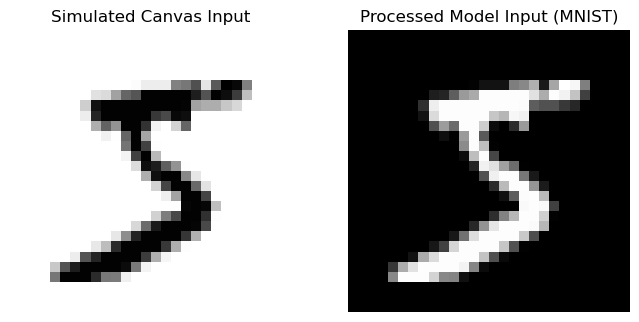

In [4]:
# We can simulate this using a raw MNIST image that we manually invert to look like canvas input.
# Our preprocessing takes care of this inversion naturally.

sample_image = images[0]
simulated_canvas = 1.0 - sample_image # White bg, dark ink

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(simulated_canvas, cmap='gray', vmin=0, vmax=1)
ax1.set_title("Simulated Canvas Input")
ax1.axis('off')

ax2.imshow(sample_image, cmap='gray', vmin=0, vmax=1)
ax2.set_title("Processed Model Input (MNIST)")
ax2.axis('off')

plt.show()

## Key Takeaways
- Data scaling to [0.0, 1.0] stabilizes gradient descent.
- The model expects specific structural conventions (e.g. background color). Real-world inputs must be preprocessed to match these conventions.

## Interview Questions
- **Why normalize MNIST pixels?** Normalizing to [0, 1] keeps numeric values small, helping gradients remain stable and preventing exploding/vanishing gradients during backpropagation.
- **How does background color affect ML models?** Neural networks learn pixel intensity patterns. If trained on black backgrounds (0) and tested on white backgrounds (1), the input layer sees massive activation spikes completely misaligned with its training, leading to total failure.